# Shared latent rollout across mechanical datasets

Train one 2D autoencoder and one frame-0 latent propagator jointly across Reid, low-temperature de Pablo, and mixed-temperature de Pablo. The rollout begins from the static reference frame and never receives history, a dataset label, or explicit temperature.

In [5]:
%matplotlib inline
import hashlib, json, os, sys
from pathlib import Path
os.environ.setdefault('MPLCONFIGDIR', '/tmp/matplotlib')
PROJECT_ROOT = Path.cwd().resolve()
while PROJECT_ROOT != PROJECT_ROOT.parent and not (PROJECT_ROOT/'src'/'lss').exists(): PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT/'src') not in sys.path: sys.path.insert(0, str(PROJECT_ROOT/'src'))
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from lss.latent.experiment import run_latent_experiment, seed_everything
from lss.latent.simulation import pearson_r, r2_score
from lss.plotting import PAPER_COLORS, apply_editorial_style, dataset_color, style_axes
from lss.utils import resolve_device
apply_editorial_style(); DEVICE = resolve_device('auto'); DEVICE

'cuda'

## Configuration

In [6]:
SEED = 20260806
FORCE_TRAIN = False
TRAIN_PER_SOURCE = 5
VAL_PER_SOURCE = 15
LATENT_DIM = 2
ROLLOUT_STEPS = [25, 50, 75, 100, 125, 150, 175, 199]
DATASETS = {
    'reid': {'label': 'Reid', 'path': PROJECT_ROOT/'data'/'reid_200_frames.pt'},
    'depablo_low_temp': {'label': 'de Pablo low-T', 'path': PROJECT_ROOT/'data'/'depablo-near-zero-temp.pt'},
    'depablo_mixed_temp': {'label': 'de Pablo mixed-T', 'path': PROJECT_ROOT/'data'/'depablo-10k-mix-temp.pt'},
}
for spec in DATASETS.values(): assert spec['path'].exists(), spec['path']
OUTPUT = PROJECT_ROOT/'notebooks'/'results'/'06b_mixed_dataset_shared_latent_rollout'
OUTPUT.mkdir(parents=True, exist_ok=True)
MODEL_CONFIG = {
    'latent_dim': LATENT_DIM, 'latent_tokens': 32, 'hidden_size': 96,
    'autoencoder_model': 'attention', 'batch_graphs': 32,
    'ae_max_train_frames_per_sim': 200, 'ae_val_frame_skip': 4, 'ae_max_val_frames_per_sim': 200,
    'ae_max_epochs': 100, 'ae_patience': 10, 'ae_lr': 1e-4, 'ae_weight_decay': 1e-5,
    'dyn_max_train_transitions_per_sim': 150, 'dyn_max_epochs': 80, 'dyn_patience': 12,
    'dyn_lr': 2e-4, 'dyn_weight_decay': 1e-5, 'propagator_hidden_size': 128,
    'propagator_objective': 'one_step', 'propagator_model': 'delta_mlp',
    'propagator_use_static_context': True, 'graph_context_dim': 16,
}
cache_identity = {'seed': SEED, 'datasets': {k: str(v['path']) for k,v in DATASETS.items()}, 'train': TRAIN_PER_SOURCE, 'val': VAL_PER_SOURCE, 'model': MODEL_CONFIG}
cache_tag = hashlib.sha1(json.dumps(cache_identity, sort_keys=True).encode()).hexdigest()[:12]
MODEL_CACHE = OUTPUT/f'shared_no_history_cv{LATENT_DIM}_{cache_tag}.pt'
print({'device': str(DEVICE), 'training_networks': TRAIN_PER_SOURCE*len(DATASETS), 'cache': str(MODEL_CACHE)})

{'device': 'cuda', 'training_networks': 15, 'cache': '/home/alexz/Documents/course_project/notebooks/results/06b_mixed_dataset_shared_latent_rollout/shared_no_history_cv2_4e0c004e52aa.pt'}


## Shared autoencoder and propagator

In [ ]:
cfg = {
    'dataset_name': 'mixed_sources_shared', 'split_seed': SEED, 'split_stratify_temperature': False,
    'min_train_p_ratio': None, 'device': str(DEVICE), 'pos_dim': 2, 'batch_graphs': MODEL_CONFIG['batch_graphs'],
    'frame_skip': 1, 'train_frame_start_order': 0, 'latent_dim': LATENT_DIM,
    'latent_tokens': MODEL_CONFIG['latent_tokens'], 'hidden_size': MODEL_CONFIG['hidden_size'],
    'autoencoder_model': MODEL_CONFIG['autoencoder_model'], 'edge_feature_dim': 12,
    'ae_target_mode': 'normalized_delta', 'node_feature_mode': 'normalized_delta',
    'ae_max_train_frames_per_sim': MODEL_CONFIG['ae_max_train_frames_per_sim'],
    'ae_val_frame_skip': MODEL_CONFIG['ae_val_frame_skip'], 'ae_max_val_frames_per_sim': MODEL_CONFIG['ae_max_val_frames_per_sim'],
    'ae_max_epochs': MODEL_CONFIG['ae_max_epochs'], 'ae_patience': MODEL_CONFIG['ae_patience'],
    'ae_lr': MODEL_CONFIG['ae_lr'], 'ae_weight_decay': MODEL_CONFIG['ae_weight_decay'],
    'dyn_max_train_transitions_per_sim': MODEL_CONFIG['dyn_max_train_transitions_per_sim'],
    'dyn_max_epochs': MODEL_CONFIG['dyn_max_epochs'], 'dyn_patience': MODEL_CONFIG['dyn_patience'],
    'dyn_lr': MODEL_CONFIG['dyn_lr'], 'dyn_weight_decay': MODEL_CONFIG['dyn_weight_decay'],
    'propagator_hidden_size': MODEL_CONFIG['propagator_hidden_size'],
    'propagator_objective': MODEL_CONFIG['propagator_objective'], 'propagator_model': MODEL_CONFIG['propagator_model'],
    'propagator_loss': 'delta', 'propagator_step_stride': 1,
    'propagator_use_static_context': MODEL_CONFIG['propagator_use_static_context'], 'graph_context_dim': MODEL_CONFIG['graph_context_dim'],
    'propagator_context_include_temperature': False, 'propagator_context_pool': 'mean',
    'propagator_rollout_eval_every_epoch': True, 'propagator_rollout_eval_horizons': [100],
    'propagator_rollout_eval_max_sims': None, 'propagator_checkpoint_metric': 'val_rollout_p_ratio_r2', 'propagator_checkpoint_mode': 'max',
    'temperature_pratio_window': 'full', 'rollout_steps_grid': ROLLOUT_STEPS, 'rollout_eval_max_sims_per_split': None,
    'early_stop_min_delta': 1e-5, 'should_rollout': True, 'should_train_propagator': True,
    'force_train': FORCE_TRAIN, 'cache_path': str(MODEL_CACHE), 'model_seed': SEED, 'repeat_idx': 1,
}
mixture = [{'name': key, 'label': spec['label'], 'path': str(spec['path']), 'train_count': TRAIN_PER_SOURCE, 'val_count': VAL_PER_SOURCE} for key,spec in DATASETS.items()]
source = {
    'dataset_name': cfg['dataset_name'], 'source_name': 'three-source mixture', 'label': 'shared three-source no-history rollout',
    'path': str(DATASETS['reid']['path']), 'dataset_mixture': mixture,
    'target_mode': cfg['ae_target_mode'], 'ae_target_mode': cfg['ae_target_mode'], 'node_feature_mode': cfg['node_feature_mode'],
    **{key: cfg[key] for key in ['latent_dim','latent_tokens','hidden_size','autoencoder_model','edge_feature_dim','ae_max_train_frames_per_sim','ae_max_epochs','ae_patience','ae_lr','ae_weight_decay','dyn_max_train_transitions_per_sim','dyn_max_epochs','dyn_patience','dyn_lr','dyn_weight_decay','model_seed','repeat_idx']},
}
seed_everything(SEED)
result = run_latent_experiment(source, cfg, device=DEVICE)
display(result['split_info'])
display(result['ae_history'].tail()); display(result['dyn_history'].tail())

## Does additional structural diversity produce a genuinely two-dimensional latent space?

Raw coordinate correlation is shown for intuition, but it is basis-dependent. The covariance spectrum and effective rank measure whether held-out trajectories occupy both dimensions rather than collapsing onto one line.


In [ ]:
from lss.latent.training import encode_frame_latent
from lss.latent.experiment import ground_truth_p_ratio

DIAGNOSTIC_NETWORKS_PER_SOURCE = 30
DIAGNOSTIC_FRAME_STRIDE = 4
SOURCE_LABELS = {key: spec['label'] for key,spec in DATASETS.items()}
SOURCE_STYLES = {
    'Reid': ('reid','s'),
    'de Pablo low-T': ('depablo_low_temp','o'),
    'de Pablo mixed-T': ('depablo_mixed_temp','^'),
}

more_data_csv = OUTPUT/f'heldout_latents_for_dimension_{cache_tag}.csv'
if more_data_csv.exists() and not FORCE_TRAIN:
    more_frames = pd.read_csv(more_data_csv)
else:
    rows = []
    source_counts = {source_name: 0 for source_name in DATASETS}
    result['ae'].eval()
    with torch.no_grad():
        for sim_idx, sim in enumerate(result['test_data']):
            source_name = str(getattr(sim[0], 'source_name', 'unknown'))
            if source_name not in source_counts or source_counts[source_name] >= DIAGNOSTIC_NETWORKS_PER_SOURCE:
                continue
            source_counts[source_name] += 1
            frame_ids = list(range(0, len(sim), DIAGNOSTIC_FRAME_STRIDE))
            if frame_ids[-1] != len(sim)-1:
                frame_ids.append(len(sim)-1)
            final_p_ratio = ground_truth_p_ratio(sim, -1, dataset_name=source_name, cfg=cfg)
            for frame_idx in frame_ids:
                z = encode_frame_latent(
                    result['ae'], sim, frame_idx, pos_dim=2,
                    node_feature_mode=result['params']['node_feature_mode'],
                    normalizers=result['normalizers'], device=DEVICE,
                ).detach().cpu().numpy().reshape(-1)
                rows.append({
                    'dataset': SOURCE_LABELS[source_name], 'source': source_name,
                    'sim_idx': sim_idx, 'frame_idx': frame_idx,
                    'final_p_ratio': final_p_ratio, 'z0': z[0], 'z1': z[1],
                })
    more_frames = pd.DataFrame(rows)
    more_frames.to_csv(more_data_csv, index=False)

one_data_csv = PROJECT_ROOT/'notebooks'/'results'/'06_mixed_dataset_shared_latent_space'/'framewise_heldout_latents.csv'
if not one_data_csv.exists():
    raise FileNotFoundError('Run notebook 06 through its held-out latent-descriptor cell first: '+str(one_data_csv))
one_frames = pd.read_csv(one_data_csv)
one_frames = one_frames[one_frames.split.eq('test')].copy()
one_frames['dataset'] = one_frames['source'].replace(SOURCE_LABELS)
one_frames['final_p_ratio'] = one_frames['side_final_trajectory_p_ratio']
one_frames = pd.concat([
    group[group.sim_idx.isin(np.sort(group.sim_idx.unique())[:DIAGNOSTIC_NETWORKS_PER_SOURCE])]
    for _, group in one_frames.groupby('dataset', sort=False)
], ignore_index=True)

comparison_frames = pd.concat([
    one_frames[['dataset','sim_idx','frame_idx','final_p_ratio','z0','z1']].assign(training_regime='1 network per source'),
    more_frames[['dataset','sim_idx','frame_idx','final_p_ratio','z0','z1']].assign(training_regime=f'{TRAIN_PER_SOURCE} networks per source'),
], ignore_index=True).replace([np.inf,-np.inf],np.nan).dropna(subset=['z0','z1'])

def latent_dimension_row(group, training_regime, dataset):
    values = group[['z0','z1']].to_numpy(float)
    centered = values-values.mean(0,keepdims=True)
    covariance = centered.T@centered/max(len(centered)-1,1)
    eigenvalues = np.linalg.eigvalsh(covariance)[::-1].clip(min=0)
    fractions = eigenvalues/max(eigenvalues.sum(),1e-12)
    return {
        'training_regime': training_regime, 'dataset': dataset, 'n_frames': len(values),
        'absolute_z0_z1_r': abs(pearson_r(values[:,0],values[:,1])),
        'pc2_variance_fraction': fractions[1],
        'singular_value_ratio_s2_over_s1': np.sqrt(eigenvalues[1]/max(eigenvalues[0],1e-12)),
        'effective_rank': np.exp(-(fractions*np.log(fractions+1e-12)).sum()),
    }

dimension_rows = []
for regime, regime_group in comparison_frames.groupby('training_regime',sort=False):
    dimension_rows.append(latent_dimension_row(regime_group,regime,'all datasets'))
    for dataset, group in regime_group.groupby('dataset',sort=False):
        dimension_rows.append(latent_dimension_row(group,regime,dataset))
dimension_comparison = pd.DataFrame(dimension_rows)
dimension_comparison.to_csv(OUTPUT/'one_vs_more_networks_latent_dimension.csv',index=False)
display(dimension_comparison.round(3))

print('Raw held-out z0-z1 planes: one versus more training networks per source.')
all_pratio = comparison_frames.final_p_ratio.dropna()
pratio_norm = plt.Normalize(all_pratio.quantile(.01),all_pratio.quantile(.99))
fig,axes=plt.subplots(1,2,figsize=(9.4,4.0),constrained_layout=True)
for ax,regime in zip(axes,['1 network per source',f'{TRAIN_PER_SOURCE} networks per source']):
    plot_frame=comparison_frames[comparison_frames.training_regime.eq(regime)]
    for dataset,group in plot_frame.groupby('dataset',sort=False):
        _,marker=SOURCE_STYLES[dataset]
        ax.scatter(group.z0,group.z1,c=group.final_p_ratio,cmap='cividis_r',norm=pratio_norm,
                   marker=marker,s=6,alpha=.16,linewidth=0,rasterized=True,label=dataset)
    style_axes(ax,xlabel=f'{regime}\nraw z0',ylabel='raw z1' if ax is axes[0] else '',legend=ax is axes[1])
    if ax.get_legend() is not None:
        for handle in ax.get_legend().legend_handles:
            handle.set_alpha(.85); handle.set_sizes([28])
fig.colorbar(plt.cm.ScalarMappable(norm=pratio_norm,cmap='cividis_r'),ax=axes,label='final p-ratio',pad=.015)
plt.show()

print('Held-out coordinate coupling and effective dimensionality. Lower |r| and effective rank nearer 2 indicate richer two-dimensional use.')
dataset_order=[*SOURCE_LABELS.values(),'all datasets']
regime_order=['1 network per source',f'{TRAIN_PER_SOURCE} networks per source']
x=np.arange(len(dataset_order)); width=.36
fig,axes=plt.subplots(1,2,figsize=(10.2,3.8),constrained_layout=True)
colors=[PAPER_COLORS['slate'],PAPER_COLORS['blue']]
for offset,regime,color in zip([-.18,.18],regime_order,colors):
    ordered=dimension_comparison[dimension_comparison.training_regime.eq(regime)].set_index('dataset').reindex(dataset_order)
    axes[0].bar(x+offset,ordered.absolute_z0_z1_r,width,color=color,label=regime)
    axes[1].bar(x+offset,ordered.effective_rank,width,color=color,label=regime)
axes[0].set(xticks=x,xticklabels=dataset_order,ylabel='|Pearson r(z0,z1)|',ylim=(0,1.05))
axes[1].set(xticks=x,xticklabels=dataset_order,ylabel='effective rank',ylim=(1,2.05))
for ax in axes:
    ax.tick_params(axis='x',rotation=22); ax.grid(False,which='both')
axes[1].legend(frameon=False)
plt.show()


## Held-out p-ratio rollout

Held-out p-ratio rollout from frame 0 using one shared model; no history, source label, or temperature is supplied.


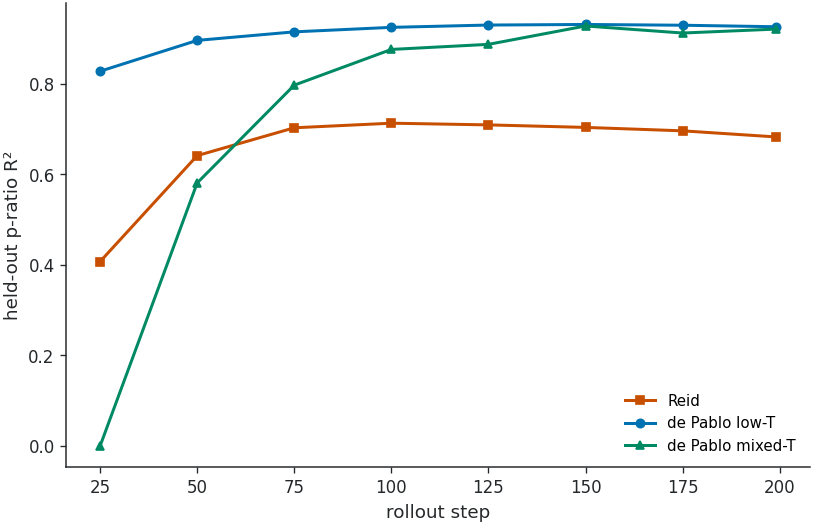

,source_family,rollout_steps,p_ratio_r2,pearson_r,n_networks
0,Reid,25,0.407,0.782,72
1,Reid,50,0.641,0.836,72
2,Reid,75,0.703,0.864,72
3,Reid,100,0.713,0.879,72
4,Reid,125,0.709,0.884,72
5,Reid,150,0.704,0.879,72
6,Reid,175,0.696,0.867,72
7,Reid,199,0.683,0.851,72
8,de Pablo low-T,25,0.828,0.919,170
9,de Pablo low-T,50,0.896,0.950,170


Held-out shared rollout at frame 100.


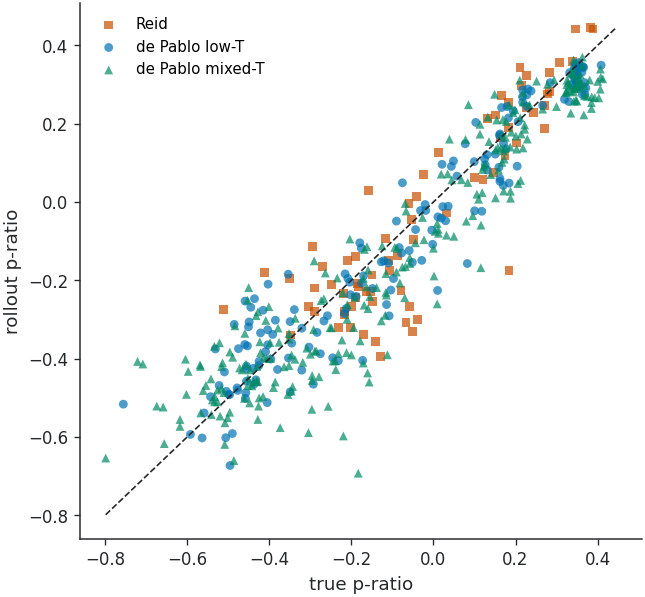

Held-out shared rollout at frame 150.


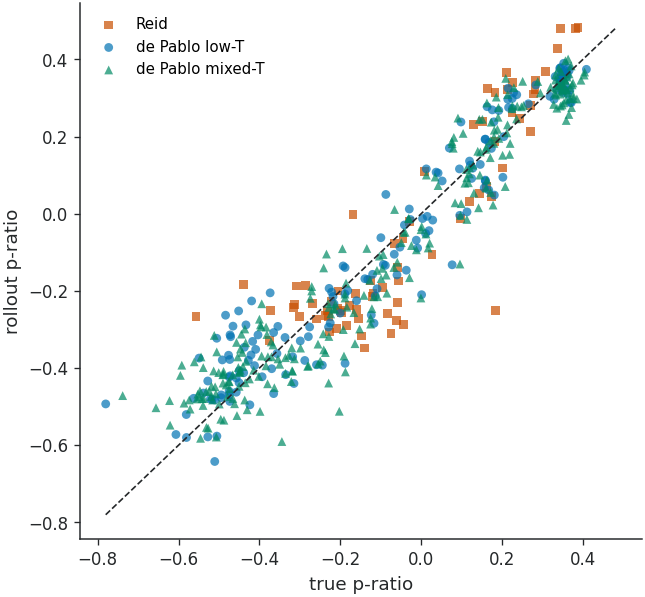

In [ ]:
SOURCE_LABELS = {key: spec['label'] for key,spec in DATASETS.items()}
SOURCE_STYLES = {'Reid': ('reid','s'), 'de Pablo low-T': ('depablo_low_temp','o'), 'de Pablo mixed-T': ('depablo_mixed_temp','^')}
test_source = {index: SOURCE_LABELS.get(str(getattr(sim[0], 'source_name', '')), str(getattr(sim[0], 'source_name', 'unknown'))) for index,sim in enumerate(result['test_data'])}
rollout_rows = result['rollout_rows'].query("split == 'test'").copy()
rollout_rows['source_family'] = rollout_rows.sim_idx.map(test_source)
rollout_rows.to_csv(OUTPUT/'heldout_rollout_rows_by_source.csv', index=False)
summary_rows = []
for (source_family, step), group in rollout_rows.groupby(['source_family','rollout_steps']):
    valid = group[['true_p_ratio','pred_p_ratio']].dropna()
    summary_rows.append({'source_family': source_family, 'rollout_steps': int(step), 'p_ratio_r2': r2_score(valid.true_p_ratio, valid.pred_p_ratio), 'pearson_r': pearson_r(valid.true_p_ratio, valid.pred_p_ratio), 'n_networks': len(valid)})
rollout_summary = pd.DataFrame(summary_rows)
rollout_summary.to_csv(OUTPUT/'heldout_pratio_rollout_by_source.csv', index=False)
print('Held-out p-ratio rollout from frame 0 using one shared model; no history, source label, or temperature is supplied.')
fig, ax = plt.subplots(figsize=(6.8,4.4), constrained_layout=True)
for source_family, group in rollout_summary.groupby('source_family', sort=False):
    key, marker = SOURCE_STYLES[source_family]
    group = group.sort_values('rollout_steps')
    ax.plot(group.rollout_steps, np.maximum(group.p_ratio_r2, 0), color=dataset_color(key), marker=marker, lw=1.8, ms=5, label=source_family)
style_axes(ax, xlabel='rollout step', ylabel='held-out p-ratio R²', legend=True)
plt.show(); display(rollout_summary.round(3))

for step in [100,150]:
    selected = rollout_rows[rollout_rows.rollout_steps.eq(step)].dropna(subset=['true_p_ratio','pred_p_ratio'])
    print(f'Held-out shared rollout at frame {step}.')
    fig, ax = plt.subplots(figsize=(5.4,5.0), constrained_layout=True)
    for source_family, group in selected.groupby('source_family', sort=False):
        key, marker = SOURCE_STYLES[source_family]
        ax.scatter(group.true_p_ratio, group.pred_p_ratio, s=28, alpha=.7, marker=marker, color=dataset_color(key), edgecolor='none', label=source_family)
    limits=np.r_[selected.true_p_ratio,selected.pred_p_ratio]; lo,hi=np.nanmin(limits),np.nanmax(limits)
    ax.plot([lo,hi],[lo,hi],'--',color=PAPER_COLORS['ink'],lw=1)
    style_axes(ax,xlabel='true p-ratio',ylabel='rollout p-ratio',legend=True)
    plt.show()